<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG + IMPORTS

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from google.colab import drive
drive.mount("/content/drive")

DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12
})

print("Imports ready.")

Mounted at /content/drive
Imports ready.


In [2]:
# LOAD ALL RESULTS
# Reads individual CSV files saved by each notebook.
# If CSVs don't exist yet (models not run), results entered manually below.


# OPTION A: Auto-load from CSV files

csv_files = glob.glob(os.path.join(DRIVE_OUT_DIR, "*_toniot_results.csv"))
print(f"Found {len(csv_files)} result CSVs:")

auto_rows = []
for f in sorted(csv_files):
    try:
        row = pd.read_csv(f).iloc[0].to_dict()
        auto_rows.append(row)
        print(f"  ✓ {os.path.basename(f)} — {row.get('model','?')}")
    except Exception as e:
        print(f"  ✗ {os.path.basename(f)}: {e}")

if auto_rows:
    df_auto = pd.DataFrame(auto_rows)
    print(f"\nLoaded {len(df_auto)} models from CSVs.")


# OPTION B: Manual entry (fill in after running each model)
# Replace None with actual values

manual_data = [
    # {"model":"RealMLP",      "accuracy":None, "f1_macro":None, "f1_weighted":None,
    #  "precision_macro":None, "recall_macro":None, "mcc":None, "cohen_kappa":None, "roc_auc_macro":None},
    # {"model":"TabM",         "accuracy":None, ...},
    # Add rows as needed
]

if manual_data and manual_data[0].get("accuracy") is not None:
    df_manual = pd.DataFrame(manual_data)
    results = df_manual
    print(f"Using manual data: {len(results)} models.")
elif auto_rows:
    results = df_auto
    print(f"Using auto-loaded CSVs: {len(results)} models.")
else:
    raise ValueError("No results found! Run model notebooks first, or fill in manual_data above.")

# Standardise column names
col_map = {
    "cohen_kappa": "cohen_kappa",
    "cohens_kappa": "cohen_kappa",
    "roc_auc": "roc_auc_macro",
}
results = results.rename(columns=col_map)

# Sort by accuracy descending for consistent ordering
results = results.sort_values("accuracy", ascending=False).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"  MODELS LOADED: {len(results)}")
print(f"{'='*60}")
for i, row in results.iterrows():
    print(f"  {i+1}. {row['model']}")
print()
print(results[["model","accuracy","f1_macro","precision_macro","recall_macro","mcc","cohen_kappa","roc_auc_macro"]].round(4).to_string(index=False))

Found 10 result CSVs:
  ✓ amformer_toniot_results.csv — AMFormer
  ✓ dofen_toniot_results.csv — DOFEN
  ✓ excelformer_toniot_results.csv — ExcelFormer
  ✓ gandalf_toniot_results.csv — GANDALF
  ✓ grande_toniot_results.csv — GRANDE
  ✓ modernnca_toniot_results.csv — ModernNCA
  ✓ realmlp_toniot_results.csv — RealMLP
  ✓ tabm_toniot_results.csv — TabM
  ✓ tabnsa_toniot_results.csv — TabNSA
  ✓ xrfm_toniot_results.csv — xRFM

Loaded 10 models from CSVs.
Using auto-loaded CSVs: 10 models.

  MODELS LOADED: 10
  1. RealMLP
  2. ExcelFormer
  3. TabNSA
  4. xRFM
  5. TabM
  6. GRANDE
  7. DOFEN
  8. ModernNCA
  9. AMFormer
  10. GANDALF

      model  accuracy  f1_macro  precision_macro  recall_macro    mcc  cohen_kappa  roc_auc_macro
    RealMLP    0.9875    0.9593           0.9558        0.9632 0.9856       0.9856         0.9994
ExcelFormer    0.9851    0.9592           0.9530        0.9672 0.9830       0.9830         0.9996
     TabNSA    0.9837    0.9524           0.9510        0.9542 0.9

In [3]:
#  COLOUR PALETTE (one colour per paradigm)
# Ensures models from the same paradigm share a colour family.

paradigm_map = {
    "RealMLP":     "MLP-based",
    "TabM":        "MLP-based",
    "GANDALF":     "MLP-based",
    "ExcelFormer": "Attention",
    "AMFormer":    "Attention",
    "TabNSA":      "Attention",
    "xRFM":        "Tree (standard)",
    "GRANDE":      "Tree (standard)",
    "DOFEN":       "Tree (oblivious)",
    "ModernNCA":   "Neighbor-based",
}

paradigm_colours = {
    "MLP-based":       "#2196F3",   # blue
    "Attention":       "#F44336",   # red
    "Tree (standard)": "#4CAF50",   # green
    "Tree (oblivious)":"#FF9800",   # orange
    "Neighbor-based":  "#9C27B0",   # purple
}

# Slight shade variation within paradigm
shade_offsets = {}
for p in paradigm_colours:
    models_in_p = [m for m, pg in paradigm_map.items() if pg == p]
    for idx, m in enumerate(models_in_p):
        shade_offsets[m] = max(0.7, 1.0 - idx * 0.15)

def get_colour(model_name):
    p = paradigm_map.get(model_name, "MLP-based")
    base = paradigm_colours[p]
    alpha = shade_offsets.get(model_name, 1.0)
    import matplotlib.colors as mc
    rgb = mc.to_rgb(base)
    return tuple(c * alpha + (1 - alpha) for c in rgb)

results["colour"] = results["model"].apply(get_colour)
results["paradigm"] = results["model"].map(paradigm_map)

print("Colour palette assigned by paradigm.")

Colour palette assigned by paradigm.


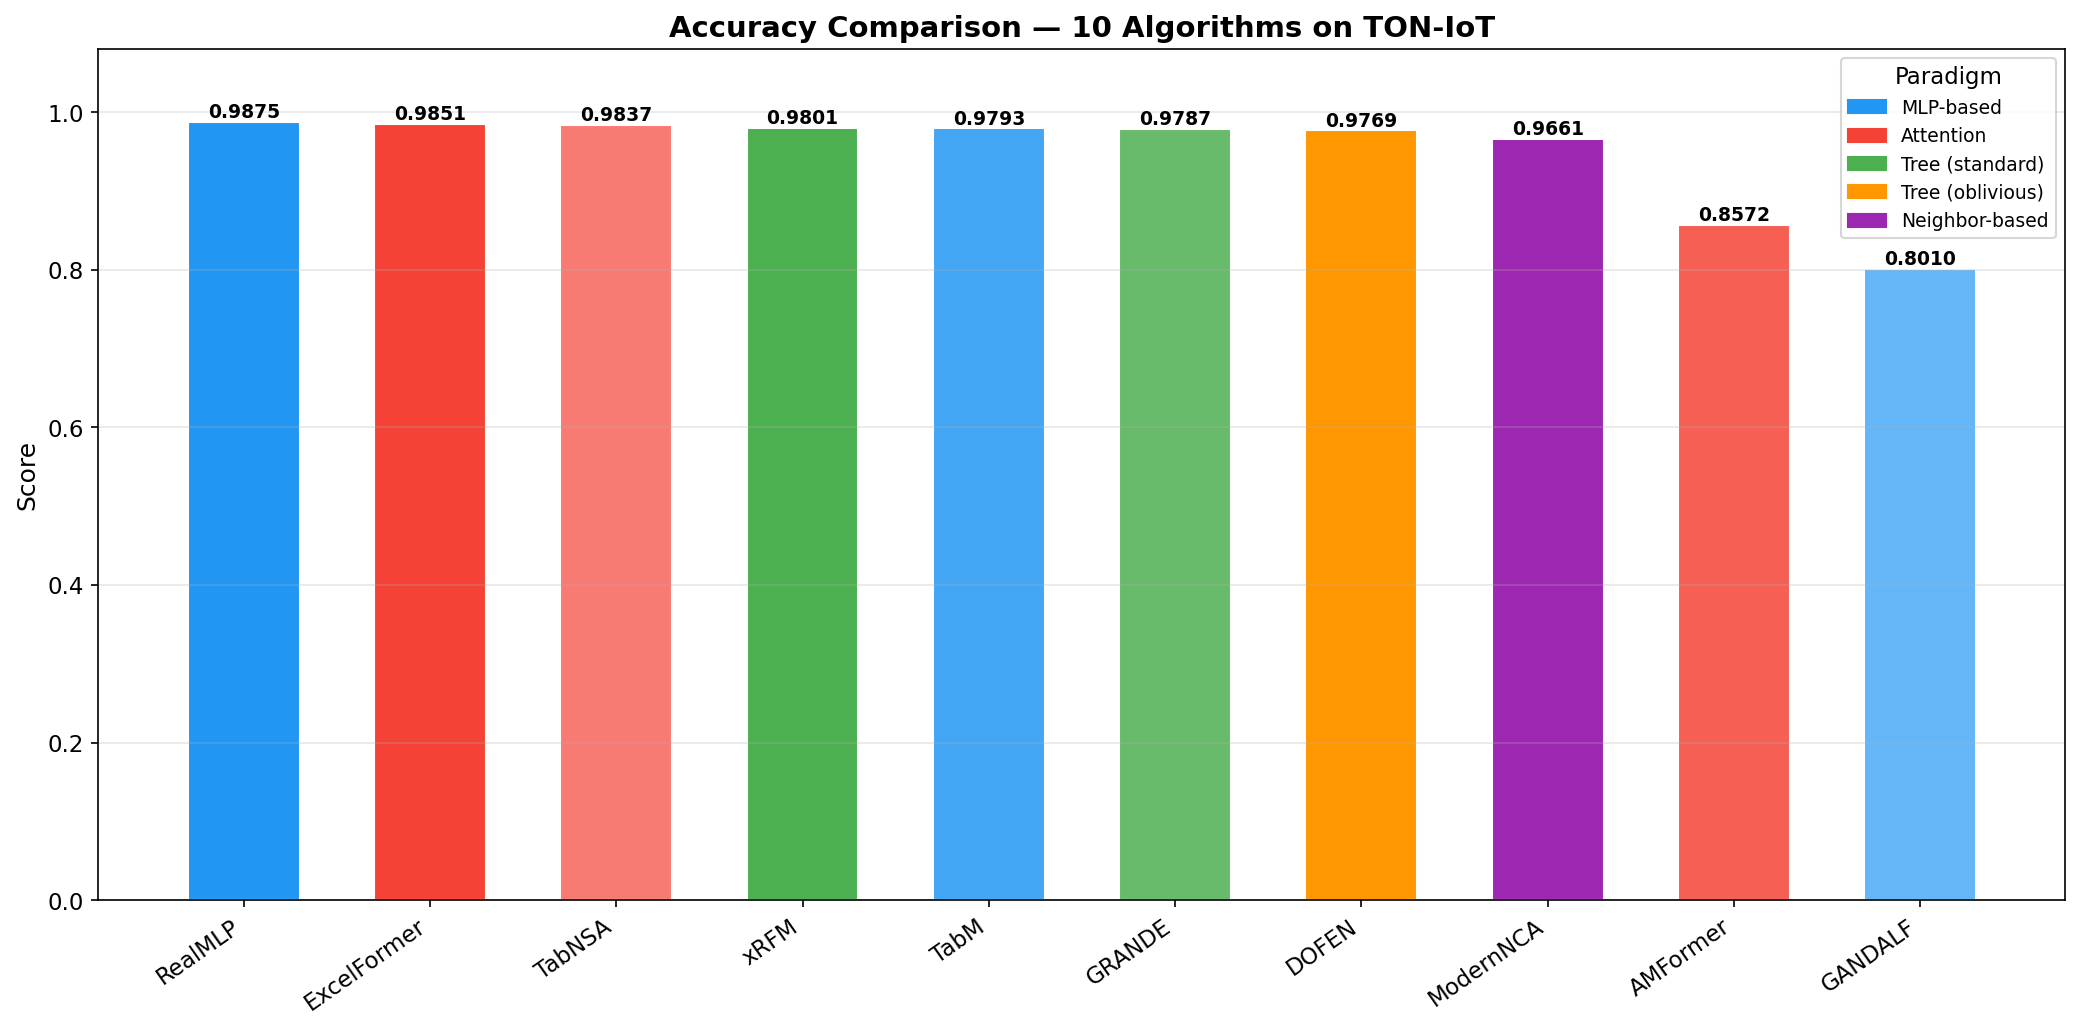

Visualisation 1 saved: comparison_1_accuracy.png


In [4]:
# VISUALISATION 1: ACCURACY COMPARISON


df_sorted = results.sort_values("accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_sorted))

bars = ax.bar(x, df_sorted["accuracy"].values, width=0.6,
              color=df_sorted["colour"].values, edgecolor="white")

for bar, val in zip(bars, df_sorted["accuracy"].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_sorted["model"].values, rotation=35, ha="right", fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Accuracy Comparison — 10 Algorithms on TON-IoT",
             fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

legend_patches = [mpatches.Patch(color=c, label=p) for p, c in paradigm_colours.items()]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, title="Paradigm")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "comparison_1_accuracy.png"), dpi=150)
plt.show()
print("Visualisation 1 saved: comparison_1_accuracy.png")

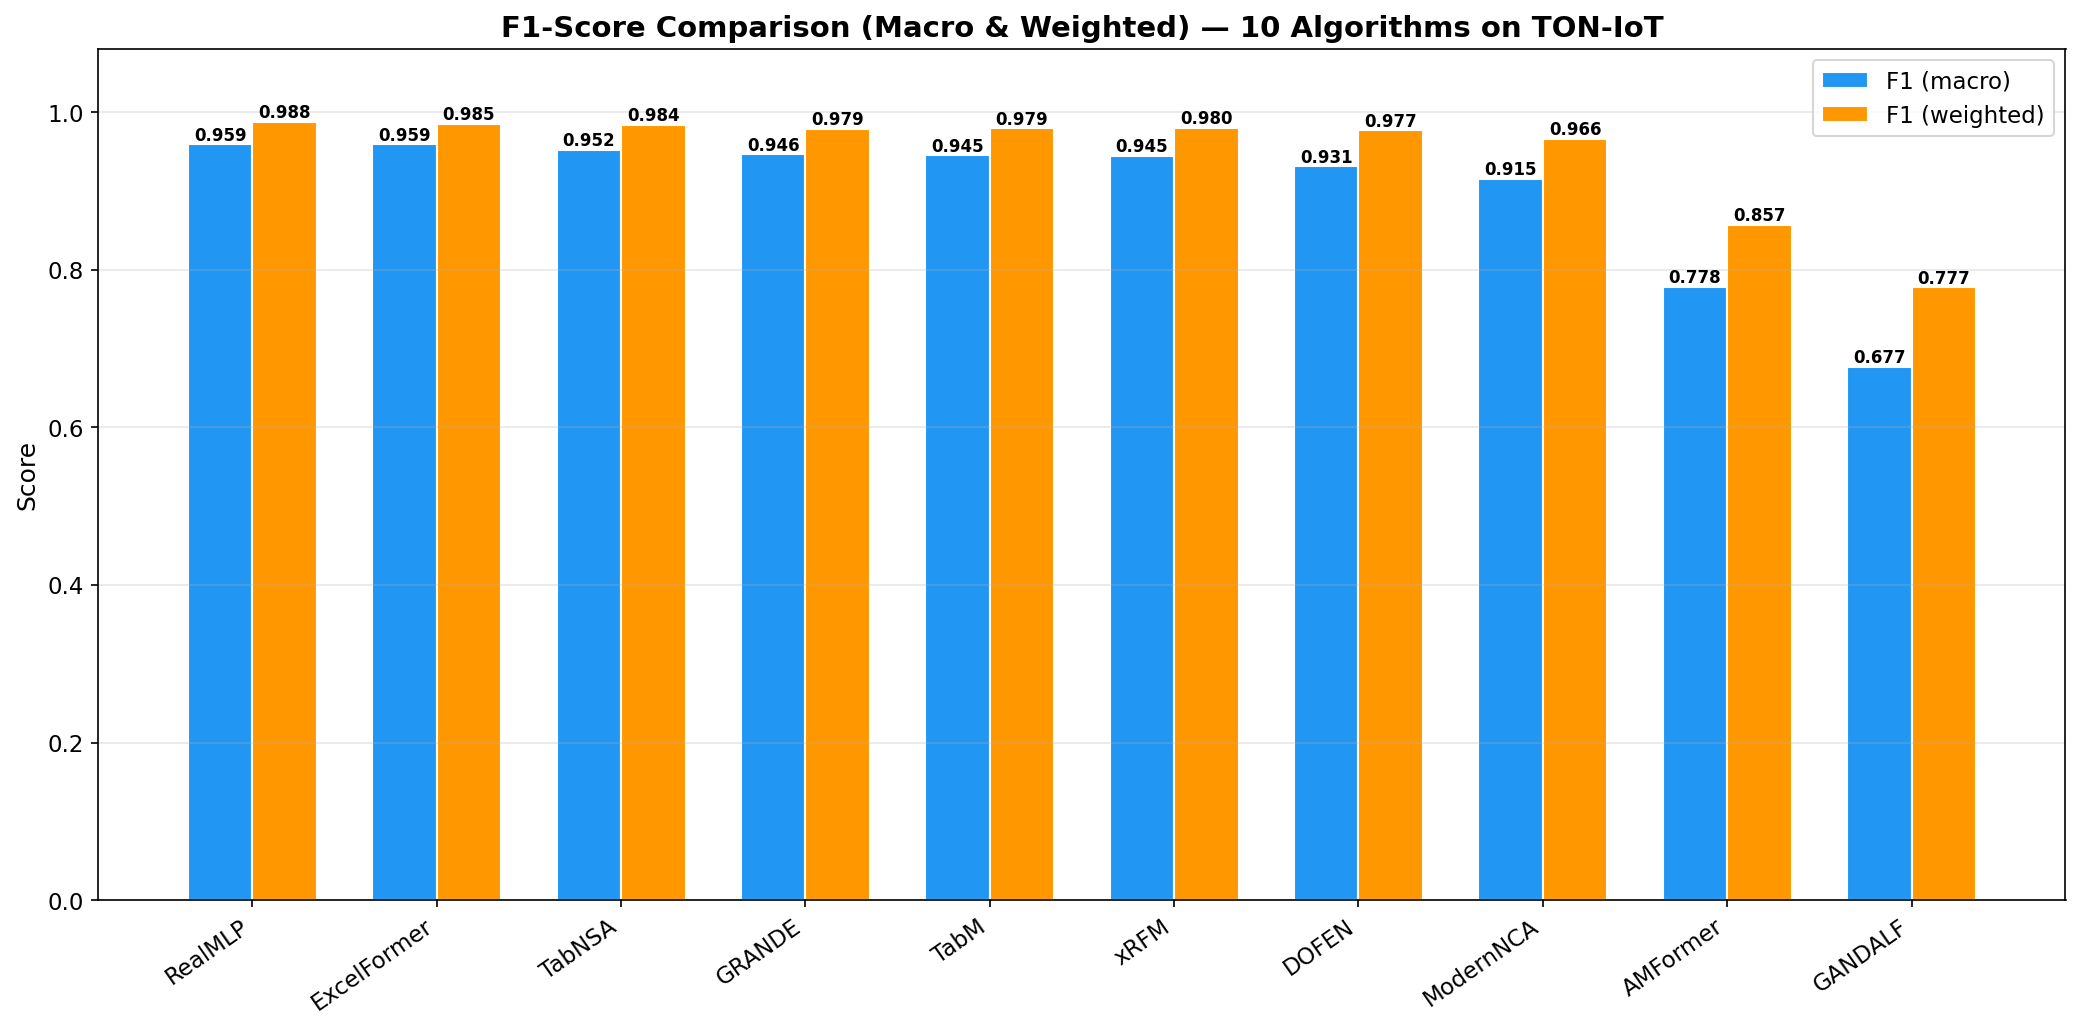

Visualisation 2 saved: comparison_2_f1_score.png


In [5]:
# VISUALISATION 2: F1-SCORE COMPARISON (MACRO + WEIGHTED)

df_sorted = results.sort_values("f1_macro", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_sorted))
w = 0.35

bars1 = ax.bar(x - w/2, df_sorted["f1_macro"].values, w,
               label="F1 (macro)", color="#2196F3", edgecolor="white")
bars2 = ax.bar(x + w/2, df_sorted["f1_weighted"].values, w,
               label="F1 (weighted)", color="#FF9800", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.3f}", ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_sorted["model"].values, rotation=35, ha="right", fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("F1-Score Comparison (Macro & Weighted) — 10 Algorithms on TON-IoT",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "comparison_2_f1_score.png"), dpi=150)
plt.show()
print("Visualisation 2 saved: comparison_2_f1_score.png")

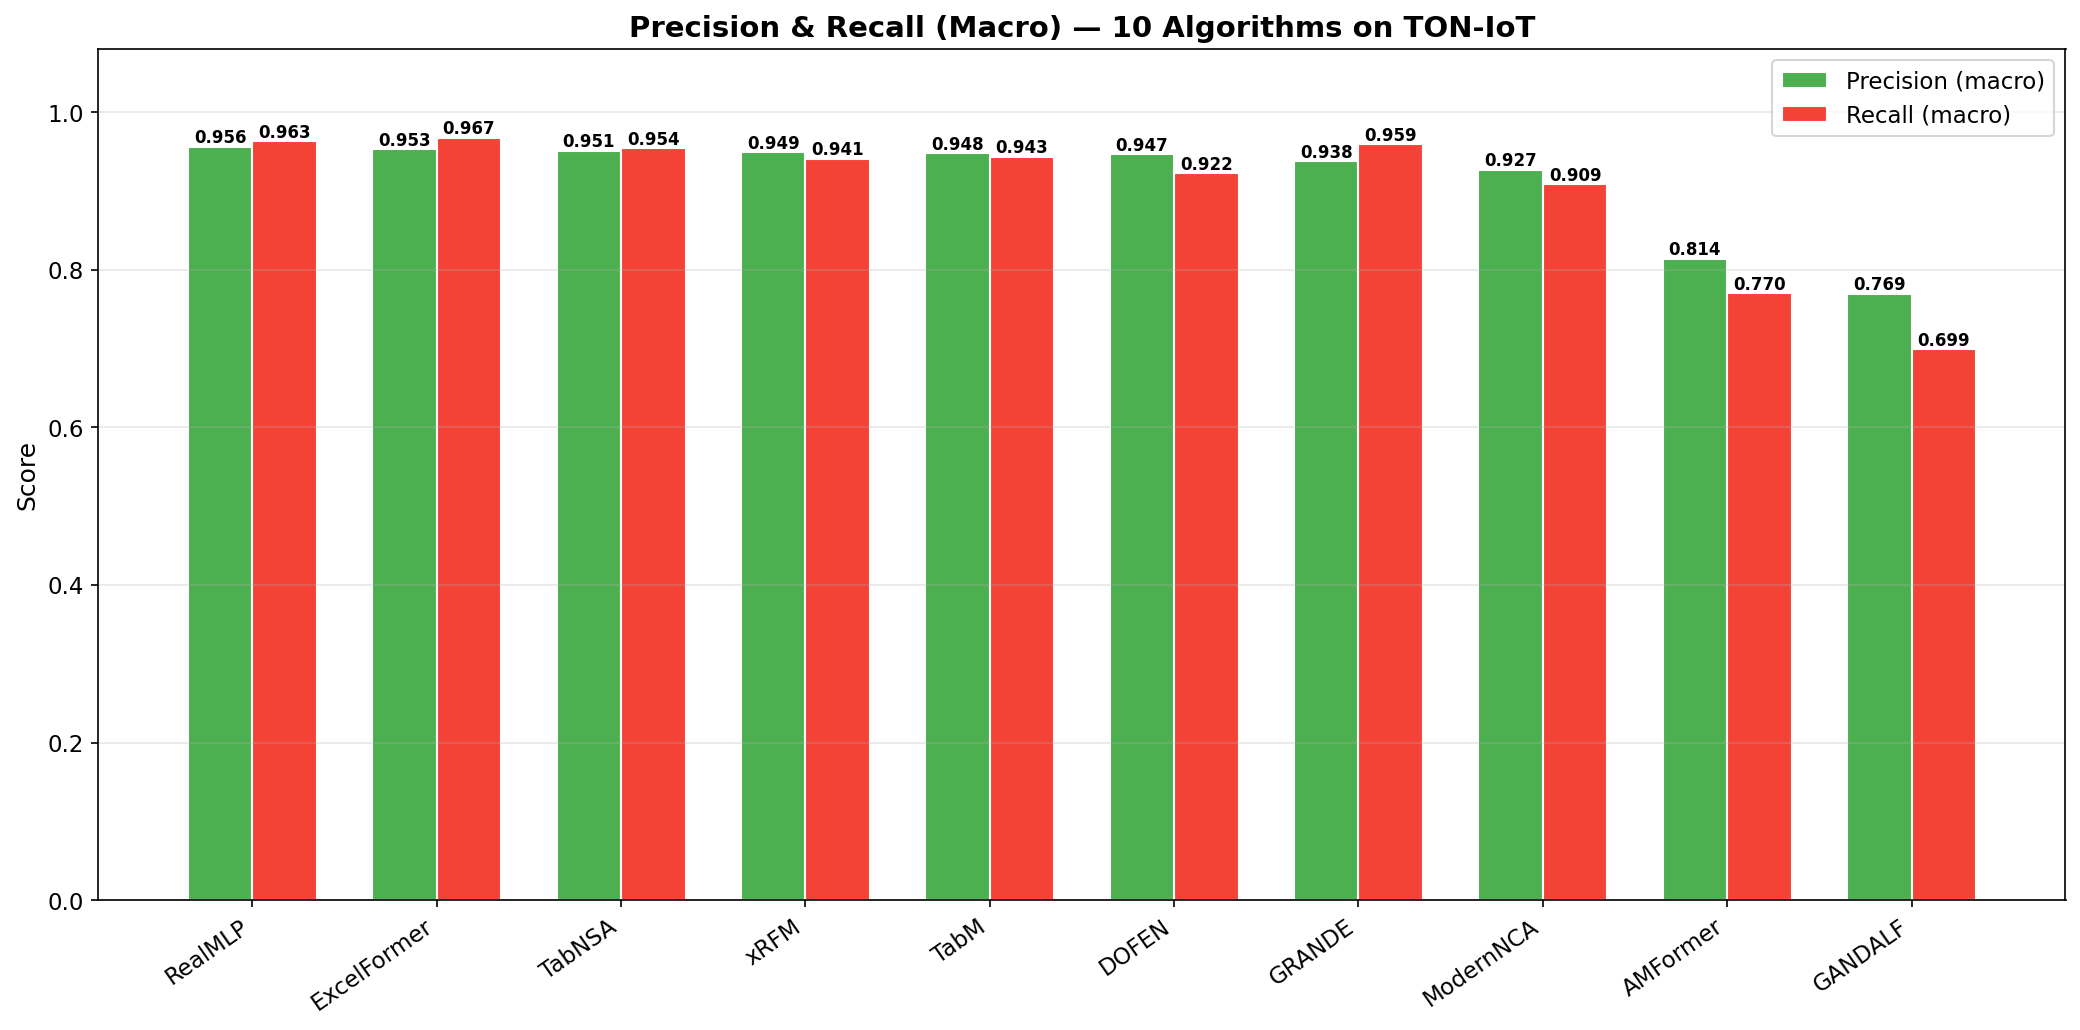

Visualisation 3 saved: comparison_3_precision_recall.png


In [6]:
# VISUALISATION 3: PRECISION & RECALL COMPARISON

df_sorted = results.sort_values("precision_macro", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_sorted))
w = 0.35

bars1 = ax.bar(x - w/2, df_sorted["precision_macro"].values, w,
               label="Precision (macro)", color="#4CAF50", edgecolor="white")
bars2 = ax.bar(x + w/2, df_sorted["recall_macro"].values, w,
               label="Recall (macro)", color="#F44336", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.3f}", ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_sorted["model"].values, rotation=35, ha="right", fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision & Recall (Macro) — 10 Algorithms on TON-IoT",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "comparison_3_precision_recall.png"), dpi=150)
plt.show()
print("Visualisation 3 saved: comparison_3_precision_recall.png")

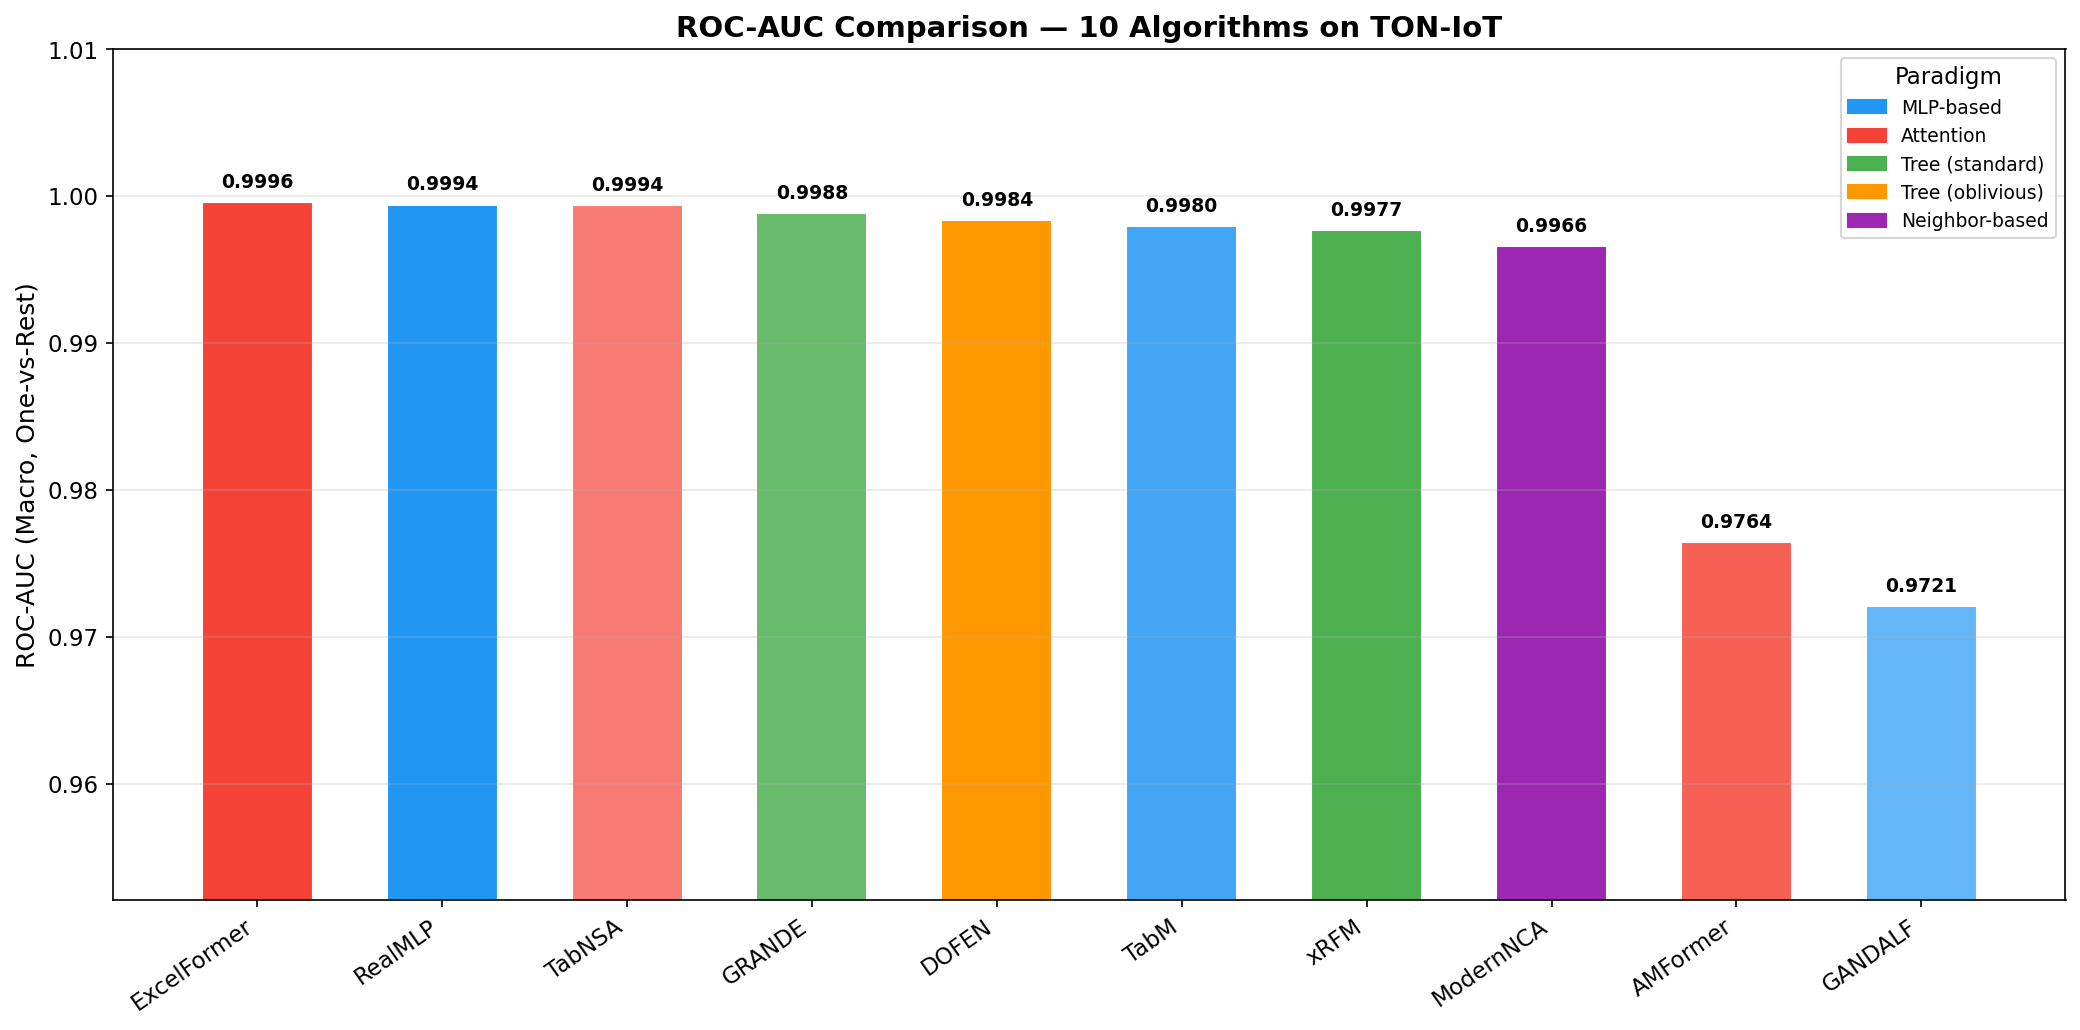

Visualisation 4 saved: comparison_4_roc_auc.png


In [7]:
# VISUALISATION 4: ROC-AUC COMPARISON

df_sorted = results.dropna(subset=["roc_auc_macro"]).sort_values("roc_auc_macro", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_sorted))

bars = ax.bar(x, df_sorted["roc_auc_macro"].values, width=0.6,
              color=df_sorted["colour"].values, edgecolor="white")

for bar, val in zip(bars, df_sorted["roc_auc_macro"].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_sorted["model"].values, rotation=35, ha="right", fontsize=11)
ax.set_ylim(df_sorted["roc_auc_macro"].min() - 0.02, 1.01)
ax.set_ylabel("ROC-AUC (Macro, One-vs-Rest)", fontsize=12)
ax.set_title("ROC-AUC Comparison — 10 Algorithms on TON-IoT",
             fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

legend_patches = [mpatches.Patch(color=c, label=p) for p, c in paradigm_colours.items()]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, title="Paradigm")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "comparison_4_roc_auc.png"), dpi=150)
plt.show()
print("Visualisation 4 saved: comparison_4_roc_auc.png")

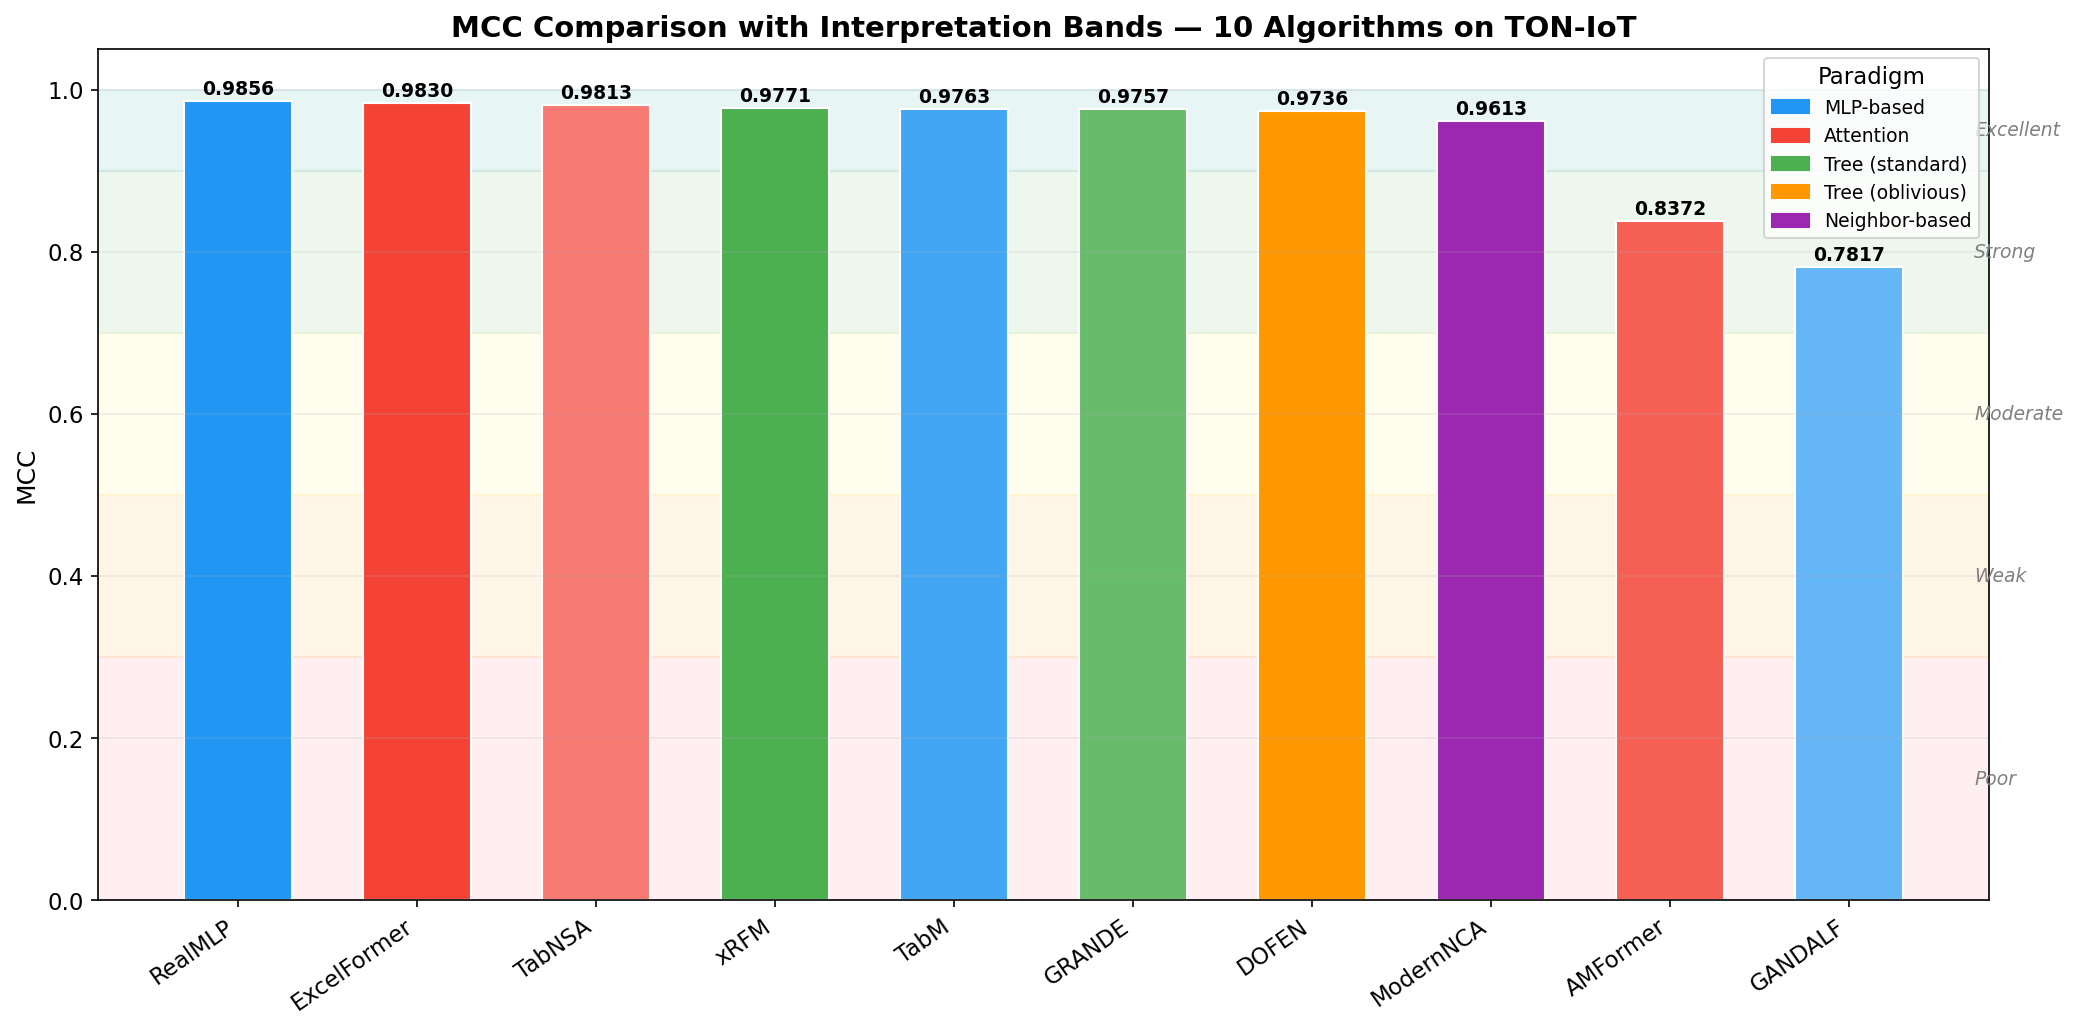

Visualisation 5 saved: comparison_5_mcc.png


In [8]:
# VISUALISATION 5: MCC COMPARISON WITH INTERPRETATION BANDS

df_sorted = results.sort_values("mcc", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_sorted))

# Horizontal interpretation bands
bands = [(0, 0.3, "#FFCDD2", "Poor"),
         (0.3, 0.5, "#FFE0B2", "Weak"),
         (0.5, 0.7, "#FFF9C4", "Moderate"),
         (0.7, 0.9, "#C8E6C9", "Strong"),
         (0.9, 1.0, "#B2DFDB", "Excellent")]

for lo, hi, colour, label in bands:
    ax.axhspan(lo, hi, alpha=0.3, color=colour)
    ax.text(len(df_sorted) - 0.3, lo + (hi - lo) / 2, label,
            va="center", fontsize=9, fontstyle="italic", color="gray")

bars = ax.bar(x, df_sorted["mcc"].values, width=0.6,
              color=df_sorted["colour"].values, edgecolor="white")

for bar, val in zip(bars, df_sorted["mcc"].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_sorted["model"].values, rotation=35, ha="right", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("MCC", fontsize=12)
ax.set_title("MCC Comparison with Interpretation Bands — 10 Algorithms on TON-IoT",
             fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.2)

legend_patches = [mpatches.Patch(color=c, label=p) for p, c in paradigm_colours.items()]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, title="Paradigm")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "comparison_5_mcc.png"), dpi=150)
plt.show()
print("Visualisation 5 saved: comparison_5_mcc.png")

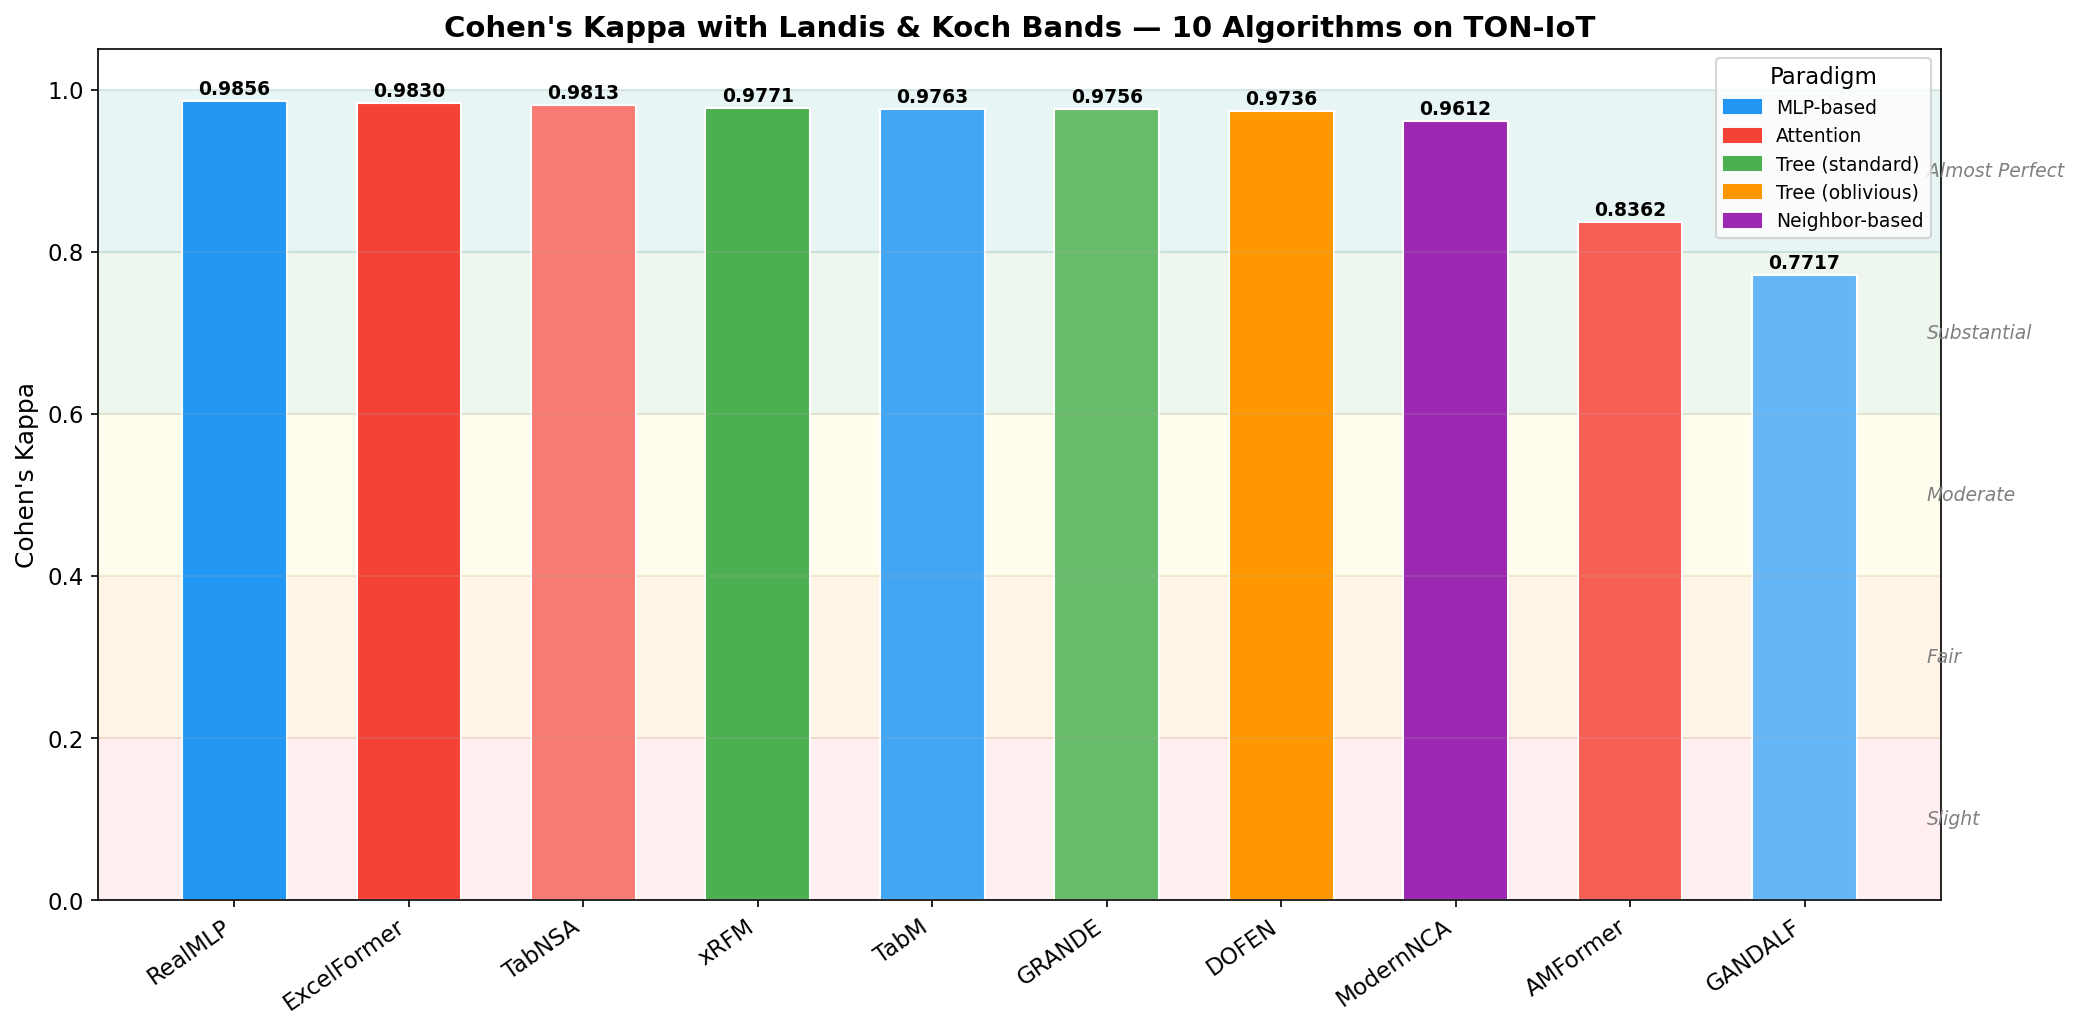

Visualisation 6 saved: comparison_6_cohen_kappa.png


In [9]:
# VISUALISATION 6: COHEN'S KAPPA WITH INTERPRETATION BANDS

df_sorted = results.sort_values("cohen_kappa", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_sorted))

# Landis & Koch bands
bands = [(0, 0.20, "#FFCDD2", "Slight"),
         (0.20, 0.40, "#FFE0B2", "Fair"),
         (0.40, 0.60, "#FFF9C4", "Moderate"),
         (0.60, 0.80, "#C8E6C9", "Substantial"),
         (0.80, 1.00, "#B2DFDB", "Almost Perfect")]

for lo, hi, colour, label in bands:
    ax.axhspan(lo, hi, alpha=0.3, color=colour)
    ax.text(len(df_sorted) - 0.3, lo + (hi - lo) / 2, label,
            va="center", fontsize=9, fontstyle="italic", color="gray")

bars = ax.bar(x, df_sorted["cohen_kappa"].values, width=0.6,
              color=df_sorted["colour"].values, edgecolor="white")

for bar, val in zip(bars, df_sorted["cohen_kappa"].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_sorted["model"].values, rotation=35, ha="right", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cohen's Kappa", fontsize=12)
ax.set_title("Cohen's Kappa with Landis & Koch Bands — 10 Algorithms on TON-IoT",
             fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.2)

legend_patches = [mpatches.Patch(color=c, label=p) for p, c in paradigm_colours.items()]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, title="Paradigm")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "comparison_6_cohen_kappa.png"), dpi=150)
plt.show()
print("Visualisation 6 saved: comparison_6_cohen_kappa.png")

In [10]:
# SUMMARY TABLE — ALL 10 ALGORITHMS × ALL METRICS


summary_cols = ["model", "accuracy", "precision_macro", "recall_macro",
                "f1_macro", "f1_weighted", "mcc", "cohen_kappa", "roc_auc_macro"]

summary = results[summary_cols].copy()
summary = summary.sort_values("accuracy", ascending=False).reset_index(drop=True)
summary.index = summary.index + 1  # rank from 1
summary.index.name = "Rank"

print("=" * 90)
print("  MASTER COMPARISON TABLE — 10 Algorithms × 8 Metrics")
print("=" * 90)
print(summary.round(4).to_string())

csv_path = os.path.join(DRIVE_OUT_DIR, "master_comparison_table.csv")
summary.to_csv(csv_path)
print(f"\nSaved: {csv_path}")

# Highlight best per metric
print("\n--- Best per Metric ---")
for col in summary_cols[1:]:
    best_row = summary.loc[summary[col].idxmax()]
    print(f"  {col:20s}: {best_row['model']} ({best_row[col]:.4f})")

  MASTER COMPARISON TABLE — 10 Algorithms × 8 Metrics
            model  accuracy  precision_macro  recall_macro  f1_macro  f1_weighted     mcc  cohen_kappa  roc_auc_macro
Rank                                                                                                                 
1         RealMLP    0.9875           0.9558        0.9632    0.9593       0.9875  0.9856       0.9856         0.9994
2     ExcelFormer    0.9851           0.9530        0.9672    0.9592       0.9853  0.9830       0.9830         0.9996
3          TabNSA    0.9837           0.9510        0.9542    0.9524       0.9837  0.9813       0.9813         0.9994
4            xRFM    0.9801           0.9490        0.9410    0.9446       0.9800  0.9771       0.9771         0.9977
5            TabM    0.9793           0.9475        0.9433    0.9453       0.9793  0.9763       0.9763         0.9980
6          GRANDE    0.9787           0.9378        0.9594    0.9465       0.9791  0.9757       0.9756         0.9988
7 